# Real Stock Screener
**Three layers:** Live data → Computed metrics → LLM-generated narrative

> Built as a response to viral AI prompt hype — this screener uses *actual* numbers, not hallucinated ones.

---
## Setup

In [2]:
# ── Dependencies ──────────────────────────────────────────────────────────────
# pip install yfinance pandas numpy requests
import yfinance as yf
import pandas as pd
import numpy as np
import requests
import json
import warnings
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print('Imports OK')

Imports OK


---
## LAYER 1 — Data Fetcher
Pull price history + fundamentals from Yahoo Finance for any tickers you provide.

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta

def get_fundamentals(tickers: list[str]) -> pd.DataFrame:
    """
    Fetch fundamental data for a list of tickers from Yahoo Finance.
    FIXED: Handles special dividends, uses quarterly data for revenue.
    """
    rows = []
    end = datetime.today()
    start = end - timedelta(days=5 * 365)

    for ticker in tickers:
        print(f'  Fetching {ticker}...', end=' ')
        try:
            t = yf.Ticker(ticker)
            info = t.info

            # ── Price history ──────────────────────────────────────────────
            hist = (
                t.history(
                    start=start.strftime('%Y-%m-%d'),
                    end=end.strftime('%Y-%m-%d'),
                    interval='1mo'
                )['Close']
                .dropna()
            )

            # ── Revenue history (IMPROVED: uses quarterly data) ────────────
            try:
                # Try quarterly data first (more recent)
                quarterly = t.quarterly_financials
                if quarterly is not None and 'Total Revenue' in quarterly.index:
                    rev_series = quarterly.loc['Total Revenue'].dropna().sort_index()
                    rev_vals = rev_series.values
                    # Update revenue_ttm with sum of last 4 quarters
                    if len(rev_vals) >= 4:
                        ttm_revenue = rev_vals[-4:].sum()
                        info['totalRevenue'] = ttm_revenue
                else:
                    # Fall back to annual data
                    financials = t.financials
                    if financials is not None and 'Total Revenue' in financials.index:
                        rev_series = financials.loc['Total Revenue'].dropna().sort_index()
                        rev_vals = rev_series.values
                    else:
                        rev_vals = np.array([])
            except Exception:
                rev_vals = np.array([])

            # ── Net Income for margin calculation ──────────────────────────
            net_income = None
            try:
                # Try quarterly first
                if quarterly is not None and 'Net Income' in quarterly.index:
                    ni_series = quarterly.loc['Net Income'].dropna().sort_index()
                    if len(ni_series) >= 4:
                        net_income = ni_series[-4:].sum()
                    elif len(ni_series) > 0:
                        net_income = ni_series[-1]
                else:
                    financials = t.financials
                    if financials is not None and 'Net Income' in financials.index:
                        ni_series = financials.loc['Net Income'].dropna().sort_index()
                        if len(ni_series) > 0:
                            net_income = ni_series[-1]
            except Exception:
                pass

            # ── Dividend yield cleanup (FIXED: handles special dividends) ──
            div_yield = info.get('dividendYield')
            if div_yield is not None:
                div_yield = float(div_yield)
                # Yahoo sometimes returns 0.0047 and sometimes 0.47
                if div_yield < 0.05:
                    div_yield = div_yield * 100
                
                # Check for special dividends ( > 5% yield is suspicious)
                if div_yield > 5.0:
                    # Try to get regular dividend yield
                    regular_yield = info.get('trailingAnnualDividendYield')
                    if regular_yield is not None and regular_yield > 0:
                        if regular_yield < 0.05:
                            regular_yield = regular_yield * 100
                        # Use the lower of the two (more conservative)
                        div_yield = min(div_yield, regular_yield)
                    else:
                        # If no regular yield available, cap at 4%
                        div_yield = min(div_yield, 4.0)

            rows.append({
                'ticker': ticker.upper(),
                'name': info.get('longName', ticker),
                'sector': info.get('sector', 'Unknown'),
                'industry': info.get('industry', 'Unknown'),
                'current_price': info.get('currentPrice') or info.get('regularMarketPrice'),
                'market_cap': info.get('marketCap'),
                'pe_ratio': info.get('trailingPE'),
                'fwd_pe': info.get('forwardPE'),
                'eps': info.get('trailingEps'),
                'revenue_ttm': info.get('totalRevenue'),
                'net_income_ttm': net_income,  # New field
                'gross_margin': info.get('grossMargins'),
                'net_margin': info.get('profitMargins'),  # Will be recalculated
                'roe': info.get('returnOnEquity'),
                'total_debt': info.get('totalDebt'),
                'total_equity': info.get('totalStockholderEquity'),
                'debt_to_equity': info.get('debtToEquity'),
                'current_ratio': info.get('currentRatio'),
                'dividend_yield': div_yield,
                'payout_ratio': info.get('payoutRatio'),
                'beta': info.get('beta'),
                '52w_high': info.get('fiftyTwoWeekHigh'),
                '52w_low': info.get('fiftyTwoWeekLow'),
                'analyst_mean_target': info.get('targetMeanPrice'),
                'analyst_low_target': info.get('targetLowPrice'),
                'analyst_high_target': info.get('targetHighPrice'),
                'recommendation': info.get('recommendationKey', 'n/a'),
                '_hist': hist,
                '_rev_vals': rev_vals,
            })
            print('✓')
        except Exception as e:
            print(f'✗ ({e})')

    return pd.DataFrame(rows)


# ── Run it ──────────────────────────────────────────────────────────────────
RAW_INPUT = input(
    "Enter tickers (comma-separated, e.g. AAPL,MSFT,NVDA,RELIANCE.NS): "
)

tickers = [
    t.strip().upper()
    for t in RAW_INPUT.split(',')
    if t.strip()
]

print(f'\nFetching data for: {tickers}\n')
raw_df = get_fundamentals(tickers)
print(f'\nFetched {len(raw_df)} tickers.')


Fetching data for: ['TCS.NS', 'META']

  Fetching TCS.NS... ✓
  Fetching META... ✓

Fetched 2 tickers.


---
## LAYER 2 — Metric Engine
Compute every metric from raw data. Nothing invented — every number traces back to yfinance.

In [4]:
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────────────────────────────────────
# LAYER 2 · compute_metrics(df)
# Derives all screener metrics from raw fundamentals.
# ─────────────────────────────────────────────────────────────────────────────

def _revenue_cagr(rev_vals: np.ndarray, years: int = 5) -> float | None:
    """
    CAGR of revenue over the last `years` periods.
    FIXED: Uses all available data points for accurate CAGR calculation.
    """
    if len(rev_vals) < 2:
        return None
    
    # Take the last 'years' number of periods
    v = rev_vals[-min(years, len(rev_vals)):]
    
    # Ensure chronological order (oldest to newest)
    if len(v) > 1 and v[0] > v[-1]:
        v = v[::-1]
    
    if v[0] <= 0 or v[-1] <= 0:
        return None
    
    # Use ALL available years for CAGR calculation
    n = len(v) - 1
    cagr = (v[-1] / v[0]) ** (1 / n) - 1
    
    # Cap at realistic values (-50% to +100% is reasonable range)
    if cagr > 1.0 or cagr < -0.5:
        return None
    
    return cagr


def _annualised_volatility(hist: pd.Series) -> float | None:
    """Annualised vol from monthly close prices."""
    if len(hist) < 6:
        return None
    monthly_returns = hist.pct_change().dropna()
    return float(monthly_returns.std() * np.sqrt(12))


def _risk_score(row: pd.Series) -> tuple[int, str]:
    """
    Risk score 1–10 (1 = very low, 10 = very high).
    Weighted composite of: beta, annualised vol, debt/equity, current ratio.
    FIXED: Properly handles D/E ratio (Yahoo returns it as percentage).
    """
    score = 5.0  # start neutral
    reasons = []

    beta = row.get('beta')
    if pd.notna(beta):
        adj = (beta - 1.0) * 1.5        # +1.5 per unit above 1
        score += adj
        if beta > 1.3:
            reasons.append(f'high beta ({beta:.2f})')
        elif beta < 0.7:
            reasons.append(f'low beta ({beta:.2f})')

    vol = row.get('ann_volatility')
    if pd.notna(vol):
        if vol > 0.45:
            score += 2
            reasons.append(f'high vol ({vol*100:.0f}%)')
        elif vol > 0.25:
            score += 1
            reasons.append(f'moderate vol ({vol*100:.0f}%)')
        else:
            score -= 1
            reasons.append(f'low vol ({vol*100:.0f}%)')

    # ── FIXED: D/E ratio handling ──────────────────────────────────────────
    dte = row.get('debt_to_equity')
    if pd.notna(dte) and dte > 0:
        # Yahoo returns D/E as a percentage (e.g., 50 = 50%)
        # Convert to raw decimal for comparison
        dte_raw = dte / 100
        
        if dte_raw > 2.0:  # 200% D/E
            score += 2
            reasons.append(f'heavy debt (D/E {dte:.0f}%)')
        elif dte_raw > 1.0:  # 100% D/E
            score += 1
            reasons.append(f'moderate debt (D/E {dte:.0f}%)')
        elif dte_raw < 0.3:  # 30% D/E
            score -= 0.5
            reasons.append(f'very low debt (D/E {dte:.0f}%)')

    cr = row.get('current_ratio')
    if pd.notna(cr):
        if cr < 1.0:
            score += 1.5
            reasons.append(f'liquidity risk (CR {cr:.2f})')
        elif cr > 2.0:
            score -= 0.5
            reasons.append(f'strong liquidity (CR {cr:.2f})')

    score = int(round(np.clip(score, 1, 10)))
    reason_str = '; '.join(reasons) if reasons else 'average risk profile'
    return score, reason_str


def _dividend_sustainability(row: pd.Series) -> str:
    """Rate dividend sustainability: Safe / Moderate / Stretched / No Dividend."""
    dy = row.get('dividend_yield')
    pr = row.get('payout_ratio')
    if pd.isna(dy) or dy == 0:
        return 'No Dividend'
    if pd.isna(pr):
        return 'No Dividend'
    if pr < 0.40:
        return 'Safe'
    elif pr < 0.65:
        return 'Moderate'
    else:
        return 'Stretched'


def _moat_rating(row: pd.Series) -> str:
    """
    Rough moat proxy: Strong / Moderate / Weak.
    Based on gross margin, ROE, and revenue CAGR.
    """
    score = 0
    gm = row.get('gross_margin')
    roe = row.get('roe')
    cagr = row.get('revenue_cagr_5y')

    if pd.notna(gm):
        if gm > 0.50:
            score += 2
        elif gm > 0.30:
            score += 1

    if pd.notna(roe):
        if roe > 0.20:
            score += 2
        elif roe > 0.12:
            score += 1

    if pd.notna(cagr):
        if cagr > 0.15:
            score += 2
        elif cagr > 0.07:
            score += 1

    if score >= 5:
        return 'Strong'
    elif score >= 3:
        return 'Moderate'
    else:
        return 'Weak'


def _price_targets(row: pd.Series) -> tuple[float | None, float | None]:
    """
    Bull / Bear 12-month price targets.
    Uses analyst consensus if available; falls back to vol-based ±1σ estimate.
    """
    price = row.get('current_price')
    if pd.isna(price) or price is None:
        return None, None

    bull = row.get('analyst_high_target')
    bear = row.get('analyst_low_target')

    if pd.notna(bull) and pd.notna(bear):
        return float(bull), float(bear)

    # fallback: ±1σ annual move
    vol = row.get('ann_volatility')
    if pd.notna(vol):
        return round(price * (1 + vol), 2), round(price * (1 - vol), 2)

    return None, None


def _entry_zone(row: pd.Series) -> tuple[float | None, float | None]:
    """
    Entry zone and stop-loss.
    FIXED: Stop-loss is ALWAYS 10% BELOW entry price.
    """
    price = row.get('current_price')
    if pd.isna(price) or price is None:
        return None, None

    bear = row.get('bear_target')
    low52 = row.get('52w_low')

    # Entry: use bear target or 5% below current price
    if pd.notna(bear) and bear < price:
        entry_price = bear
    else:
        entry_price = round(price * 0.95, 2)

    # FIXED: Stop-loss ALWAYS 10% BELOW entry price (NOT current price!)
    stop = round(entry_price * 0.90, 2)

    # If 52-week low is higher than calculated stop, use 52-week low as stop
    if pd.notna(low52) and low52 > stop:
        stop = round(low52 * 0.98, 2)

    # Safety check: stop should NEVER be above entry
    if stop >= entry_price:
        stop = round(entry_price * 0.95, 2)

    return round(entry_price, 2), stop


# ─────────────────────────────────────────────────────────────────────────────

def compute_metrics(raw: pd.DataFrame) -> pd.DataFrame:
    """Apply all metric functions to the raw DataFrame."""
    df = raw.copy()

    # ── Derived metrics ───────────────────────────────────────────────────────
    df['revenue_cagr_5y'] = df.apply(
        lambda r: _revenue_cagr(r['_rev_vals']), axis=1)

    df['ann_volatility'] = df.apply(
        lambda r: _annualised_volatility(r['_hist']), axis=1)

    # ── FIXED: Calculate Net Margin from TTM data ──────────────────────────
    def calc_net_margin(row):
        """Calculate net margin from TTM revenue and net income."""
        revenue = row.get('revenue_ttm')
        net_income = row.get('net_income_ttm')
        if pd.notna(revenue) and pd.notna(net_income) and revenue > 0:
            return net_income / revenue
        return row.get('net_margin')  # Fallback to Yahoo's value
    
    df['net_margin'] = df.apply(calc_net_margin, axis=1)

    # ── Sector-relative P/E ────────────────────────────────────────────────
    # Only calculate sector median if we have enough stocks per sector
    sector_counts = df.groupby('sector').size()
    valid_sectors = sector_counts[sector_counts >= 3].index  # Need at least 3 stocks
    
    if len(valid_sectors) > 0:
        sector_pe = df[df['sector'].isin(valid_sectors)].groupby('sector')['pe_ratio'].median().rename('sector_median_pe')
        df = df.join(sector_pe, on='sector')
        df['pe_vs_sector'] = df['pe_ratio'] / df['sector_median_pe']
    else:
        # If we don't have enough stocks per sector, use overall median
        overall_pe = df['pe_ratio'].median()
        df['sector_median_pe'] = overall_pe
        df['pe_vs_sector'] = df['pe_ratio'] / overall_pe

    # ── Composite metrics ──────────────────────────────────────────────────
    risk_results = df.apply(_risk_score, axis=1)
    df['risk_score'] = risk_results.apply(lambda x: x[0])
    df['risk_reasoning'] = risk_results.apply(lambda x: x[1])

    df['dividend_sustainability'] = df.apply(_dividend_sustainability, axis=1)
    df['moat_rating'] = df.apply(_moat_rating, axis=1)

    targets = df.apply(_price_targets, axis=1)
    df['bull_target'] = targets.apply(lambda x: x[0])
    df['bear_target'] = targets.apply(lambda x: x[1])
    df['target_source'] = df.apply(
        lambda r: 'analyst consensus'
        if pd.notna(r.get('analyst_high_target')) else 'vol-based ±1σ', axis=1)

    entry = df.apply(_entry_zone, axis=1)
    df['entry_low'] = entry.apply(lambda x: x[0])
    df['stop_loss'] = entry.apply(lambda x: x[1])

    return df


metrics_df = compute_metrics(raw_df)
print('✅ Metrics computed for', len(metrics_df), 'tickers')

✅ Metrics computed for 2 tickers


---
## LAYER 2b — Screener
Filter using your own criteria. All parameters are easily tunable.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# LAYER 2b · screen(df, criteria)
# Pass a dict of criteria — all are optional. Unset = no filter.
# ─────────────────────────────────────────────────────────────────────────────

def screen(df: pd.DataFrame, criteria: dict) -> pd.DataFrame:
    """
    Filter stocks by criteria dict.
    Returns DataFrame of stocks passing ALL provided criteria.
    Also adds a composite score for ranking.
    """
    filtered = df.copy()

    if 'max_pe' in criteria:
        filtered = filtered[filtered['pe_ratio'].fillna(999) <= criteria['max_pe']]

    if 'min_revenue_cagr' in criteria:
        filtered = filtered[filtered['revenue_cagr_5y'].fillna(-99) >= criteria['min_revenue_cagr']]

    if 'max_debt_to_equity' in criteria:
        # Convert to percentage for comparison (Yahoo returns D/E as %)
        filtered = filtered[filtered['debt_to_equity'].fillna(999) <= criteria['max_debt_to_equity']]

    if 'min_dividend_yield' in criteria:
        filtered = filtered[filtered['dividend_yield'].fillna(0) >= criteria['min_dividend_yield']]

    if 'max_payout_ratio' in criteria:
        filtered = filtered[filtered['payout_ratio'].fillna(99) <= criteria['max_payout_ratio']]

    if 'max_risk_score' in criteria:
        filtered = filtered[filtered['risk_score'].fillna(10) <= criteria['max_risk_score']]

    if 'min_gross_margin' in criteria:
        filtered = filtered[filtered['gross_margin'].fillna(-1) >= criteria['min_gross_margin']]

    if 'moat' in criteria:
        allowed = criteria['moat'] if isinstance(criteria['moat'], list) else [criteria['moat']]
        filtered = filtered[filtered['moat_rating'].isin(allowed)]

    if 'sectors' in criteria:
        filtered = filtered[filtered['sector'].isin(criteria['sectors'])]

    if filtered.empty:
        print('⚠️  No stocks passed the screening criteria.')
        return filtered

    # ── Composite score (for ranking) ──────────────────────────────────────
    # Normalise each metric to 0-1, then average with weights
    def norm(s):
        rng = s.max() - s.min()
        return (s - s.min()) / rng if rng > 0 else pd.Series(0.5, index=s.index)

    score = pd.Series(0.0, index=filtered.index)
    
    # ── FIXED: Rebalanced weights ──────────────────────────────────────────
    weights = [
        ('pe_vs_sector', 0.25, False),     # Valuation matters most
        ('risk_score', 0.20, False),       # Risk is crucial
        ('revenue_cagr_5y', 0.15, True),   # Growth is important but not everything
        ('gross_margin', 0.15, True),      # Profitability
        ('roe', 0.15, True),               # Efficiency
        ('dividend_yield', 0.10, True),    # Bonus for income (increased weight)
    ]
    
    total_w = 0
    for col, w, higher_better in weights:
        if col in filtered.columns and filtered[col].notna().sum() > 0:
            s = norm(filtered[col].fillna(filtered[col].median()))
            score += w * (s if higher_better else (1 - s))
            total_w += w
    if total_w > 0:
        score = score / total_w

    filtered = filtered.copy()
    filtered['composite_score'] = (score * 100).round(1)
    filtered = filtered.sort_values('composite_score', ascending=False)

    return filtered


# ── Criteria — edit to your preference ────────────────────────────────────────
CRITERIA = {
    # 'max_pe':              30,      # uncomment to filter
    # 'min_revenue_cagr':    0.05,    # 5% CAGR minimum
    # 'max_debt_to_equity':  150,     # D/E < 150% (Yahoo returns as %, so 150 = 150%)
    # 'max_risk_score':      7,
    # 'min_gross_margin':    0.20,
    # 'moat':                ['Strong', 'Moderate'],
    # 'sectors':             ['Technology', 'Healthcare'],
}

screened_df = screen(metrics_df, CRITERIA)

print(f"\n✅ {len(screened_df)} stocks passed screening.\n")

# ── Display stock details one by one ─────────────────────────────

DISPLAY_COLS = [
    'ticker', 'name', 'sector',
    'current_price', 'pe_ratio', 'pe_vs_sector',
    'revenue_cagr_5y', 'gross_margin', 'net_margin', 'roe',
    'debt_to_equity', 'dividend_yield', 'dividend_sustainability',
    'moat_rating', 'risk_score',
    'bull_target', 'bear_target', 'target_source',
    'entry_low', 'stop_loss',
    'composite_score',
]

display_cols = [c for c in DISPLAY_COLS if c in screened_df.columns]

for i, (_, row) in enumerate(screened_df.iterrows(), start=1):
    print("\n" + "=" * 100)
    print(f"STOCK #{i}: {row['ticker']}")
    print("=" * 100)
    print(f"{'Sector':<25} : {row['sector']}")
    print(f"{'Risk':<25} : {row['risk_score']}/10")
    print(f"{'Moat':<25} : {row['moat_rating']}")
    print(f"{'Score':<25} : {row['composite_score']}/100")
    print("-" * 100)

    for col in display_cols:
        if col in ['ticker', 'name', 'sector', 'moat_rating', 'dividend_sustainability', 
                   'target_source', 'recommendation']:
            continue  # Already displayed above
            
        value = row[col]
        if pd.isna(value):
            value = "N/A"
        
        # Format percentages nicely
        if col in ['revenue_cagr_5y', 'gross_margin', 'net_margin', 'roe'] and not pd.isna(row[col]):
            value = f"{value:.2%}"
        elif col == 'debt_to_equity' and not pd.isna(row[col]):
            value = f"{value:.1f}%"
        elif col == 'dividend_yield' and not pd.isna(row[col]):
            value = f"{value:.2f}%"
        elif col in ['pe_ratio', 'pe_vs_sector', 'current_price'] and not pd.isna(row[col]):
            if col == 'pe_vs_sector':
                value = f"{value:.2f}x"
            elif col == 'pe_ratio':
                value = f"{value:.2f}x"
            else:
                value = f"{value:.2f}"
        
        # Format large numbers
        if col == 'market_cap' and not pd.isna(row[col]):
            val = row[col]
            if val >= 1e12:
                value = f"${val/1e12:.2f} Trillion"
            elif val >= 1e9:
                value = f"${val/1e9:.2f} Billion"
        
        print(f"{col:<25} : {value}")

    # Add risk reasoning if available
    if 'risk_reasoning' in row and pd.notna(row['risk_reasoning']):
        print(f"{'Risk Reasoning':<25} : {row['risk_reasoning']}")
    
    # Add analyst recommendation if available
    if 'recommendation' in row and pd.notna(row['recommendation']):
        print(f"{'Analyst Consensus':<25} : {row['recommendation']}")

    print("\n")


✅ 2 stocks passed screening.


STOCK #1: TCS.NS
Sector                    : Technology
Risk                      : 2/10
Moat                      : Moderate
Score                     : 70.0/100
----------------------------------------------------------------------------------------------------
current_price             : 2093.50
pe_ratio                  : 15.38x
pe_vs_sector              : 0.84x
revenue_cagr_5y           : 2.53%
gross_margin              : 40.31%
net_margin                : 18.58%
roe                       : 48.40%
debt_to_equity            : 10.4%
dividend_yield            : 3.09%
risk_score                : 2
bull_target               : 3841.0
bear_target               : 1860.0
entry_low                 : 1860.0
stop_loss                 : 1767.0
composite_score           : 70.0
Risk Reasoning            : low beta (0.24); low vol (21%); very low debt (D/E 10%); strong liquidity (CR 2.23)
Analyst Consensus         : buy



STOCK #2: META
Sector                    :

In [6]:
print(len(screened_df))
print(screened_df[['ticker', 'name']])

2
   ticker                               name
0  TCS.NS  Tata Consultancy Services Limited
1    META               Meta Platforms, Inc.


In [7]:
import os
from dotenv import load_dotenv
from groq import Groq
import numpy as np
import pandas as pd

# Load variables from .env
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError(
        "GROQ_API_KEY not found. Please create a .env file."
    )

client = Groq(api_key=GROQ_API_KEY)

# Recommended model
MODEL_NAME = "llama-3.3-70b-versatile"

SYSTEM_PROMPT = """
You are a senior equity research analyst.

You will be given a structured data block with real,
pre-computed financial metrics for a stock.

Write a concise professional equity research note.

Requirements:
1. One-sentence investment thesis
2. Key positives using actual numbers provided
3. Key risks using actual numbers provided
4. Recommendation and target rationale

Rules:
- Use only numbers supplied.
- Do not invent metrics.
- Skip missing values.
- Professional tone.
"""


def generate_report(row: pd.Series):

    def _fmt(val, pct=False, x=False):
        if val is None or (isinstance(val, float) and np.isnan(val)):
            return "N/A"
        if pct:
            return f"{float(val)*100:.1f}%"
        if x:
            return f"{float(val):.1f}x"
        return str(round(float(val), 2)) if isinstance(val, float) else str(val)

    data_block = f"""
TICKER: {row.get('ticker')}
COMPANY: {row.get('name')}
SECTOR: {row.get('sector')}

CURRENT PRICE: {_fmt(row.get('current_price'))}

VALUATION
Trailing P/E: {_fmt(row.get('pe_ratio'), x=True)}
Forward P/E: {_fmt(row.get('fwd_pe'), x=True)}
P/E vs Sector: {_fmt(row.get('pe_vs_sector'), x=True)}

GROWTH
Revenue CAGR (5Y): {_fmt(row.get('revenue_cagr_5y'), pct=True)}
Gross Margin: {_fmt(row.get('gross_margin'), pct=True)}
Net Margin: {_fmt(row.get('net_margin'), pct=True)}
ROE: {_fmt(row.get('roe'), pct=True)}

BALANCE SHEET
Debt-to-Equity: {_fmt(row.get('debt_to_equity'))}
Current Ratio: {_fmt(row.get('current_ratio'))}

DIVIDENDS
Yield: {_fmt(row.get('dividend_yield'), pct=True)}
Payout Ratio: {_fmt(row.get('payout_ratio'), pct=True)}
Sustainability: {row.get('dividend_sustainability')}

RISK
Beta: {_fmt(row.get('beta'))}
Volatility: {_fmt(row.get('ann_volatility'), pct=True)}
Risk Score: {row.get('risk_score')}/10
Risk Reasoning: {row.get('risk_reasoning')}

MOAT
Moat Rating: {row.get('moat_rating')}

TARGETS
Bull Target: {_fmt(row.get('bull_target'))}
Bear Target: {_fmt(row.get('bear_target'))}

ENTRY ZONE
Entry: {_fmt(row.get('entry_low'))}
Stop Loss: {_fmt(row.get('stop_loss'))}

ANALYST CONSENSUS
Recommendation: {row.get('recommendation')}
Mean Target: {_fmt(row.get('analyst_mean_target'))}

COMPOSITE SCORE
{row.get('composite_score')}/100
"""

    try:

        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {
                    "role": "system",
                    "content": SYSTEM_PROMPT
                },
                {
                    "role": "user",
                    "content": data_block
                }
            ],
            temperature=0.3,
            max_tokens=800
        )

        return response.choices[0].message.content

    except Exception as e:

        return f"Groq Error: {e}"


print("✅ Groq report generator ready")

✅ Groq report generator ready


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Run reports for all screened stocks
# ─────────────────────────────────────────────────────────────────────────────

def fmt_money(x, ticker=None, field=None):

    if pd.isna(x):
        return "N/A"

    x = float(x)

    # Indian stocks
    if str(ticker).endswith(".NS"):

        # Market Cap in Trillion
        if field == "market_cap":
            return f"₹{x/1e12:.2f} Trillion"

        # Revenue / Debt / Equity in Lakh Cr
        if field in ["revenue_ttm", "total_debt", "total_equity"]:

            lakh_cr = x / 1e12

            return f"₹{lakh_cr:.2f} Lakh Cr"

        return f"₹{x:,.0f}"

    # US stocks

    if x >= 1e12:
        return f"${x/1e12:.2f} Trillion"

    if x >= 1e9:
        return f"${x/1e9:.2f} Billion"

    if x >= 1e6:
        return f"${x/1e6:.2f} Million"

    return f"${x:,.0f}"


def fmt_pct(x):

    if pd.isna(x):
        return "N/A"

    return f"{float(x)*100:.2f}%"


def fmt_dividend(v):

    if pd.isna(v):
        return "N/A"

    v = float(v)

    if v < 0.05:
        return f"{v*100:.2f}%"

    return f"{v:.2f}%"


SEPARATOR = "\n" + "─"*100 + "\n"

for _, row in screened_df.iterrows():

    print(SEPARATOR)

    print(
        f"📊 EQUITY RESEARCH NOTE — "
        f"{row.get('ticker')} ({row.get('name')})"
    )

    print(
        f"Sector: {row.get('sector')} | "
        f"Risk: {row.get('risk_score')}/10 | "
        f"Moat: {row.get('moat_rating')} | "
        f"Score: {row.get('composite_score')}/100"
    )

    print()

    metrics_display = {

        "Price":
            (
                f"₹{row.get('current_price'):.2f}"
                if str(row.get('ticker')).endswith(".NS")
                else f"${row.get('current_price'):.2f}"
            )
            if pd.notna(row.get('current_price'))
            else "N/A",

        "Market Cap":
            fmt_money(
                row.get('market_cap'),
                row.get('ticker'),
                "market_cap"
            ),

        "Annual Revenue (TTM)":
            fmt_money(
                row.get('revenue_ttm'),
                row.get('ticker'),
                "revenue_ttm"
            ),

        "P/E":
            (
                f"{row.get('pe_ratio'):.2f}x"
                if pd.notna(row.get('pe_ratio'))
                else "N/A"
            ),

        "Forward P/E":
            (
                f"{row.get('fwd_pe'):.2f}x"
                if pd.notna(row.get('fwd_pe'))
                else "N/A"
            ),

        "Gross Margin":
            fmt_pct(row.get('gross_margin')),

        "Net Margin":
            fmt_pct(row.get('net_margin')),

        "ROE":
            fmt_pct(row.get('roe')),

        "Total Debt":
            fmt_money(
                row.get('total_debt'),
                row.get('ticker'),
                "total_debt"
            ),

        "Total Equity":
            fmt_money(
                row.get('total_equity'),
                row.get('ticker'),
                "total_equity"
            ),

        "Debt / Equity":
            (
                f"{row.get('debt_to_equity'):.2f}%"
                if pd.notna(row.get('debt_to_equity'))
                else "N/A"
            ),

        "Current Ratio":
            (
                f"{row.get('current_ratio'):.2f}"
                if pd.notna(row.get('current_ratio'))
                else "N/A"
            ),

        "Dividend Yield":
            fmt_dividend(row.get('dividend_yield')),

        "Payout Ratio":
            (
                fmt_pct(row.get('payout_ratio'))
                if pd.notna(row.get('payout_ratio'))
                else "N/A"
            ),

        "Beta":
            (
                f"{row.get('beta'):.2f}"
                if pd.notna(row.get('beta'))
                else "N/A"
            ),

        "52W High":
            row.get('52w_high'),

        "52W Low":
            row.get('52w_low'),

        "Bull Target":
            row.get('bull_target'),

        "Bear Target":
            row.get('bear_target'),

        "Analyst Target":
            row.get('analyst_mean_target'),

        "Entry Zone":
            f"{row.get('entry_low')} – {row.get('current_price')}",

        "Stop Loss":
            row.get('stop_loss'),
    }

    col_w = max(len(k) for k in metrics_display.keys()) + 2

    for k, v in metrics_display.items():
        print(f"{k:<{col_w}} : {v}")

    print()

    print(
        "Risk Reasoning:",
        row.get("risk_reasoning", "N/A")
    )

    print(
        f"Target Source: {row.get('target_source', 'N/A')} | "
        f"Analyst Consensus: {row.get('recommendation', 'N/A')}"
    )

    print()


────────────────────────────────────────────────────────────────────────────────────────────────────

📊 EQUITY RESEARCH NOTE — TCS.NS (Tata Consultancy Services Limited)
Sector: Technology | Risk: 2/10 | Moat: Moderate | Score: 70.0/100

Price                  : ₹2093.50
Market Cap             : ₹7.57 Trillion
Annual Revenue (TTM)   : ₹2.66 Lakh Cr
P/E                    : 15.38x
Forward P/E            : 12.74x
Gross Margin           : 40.31%
Net Margin             : 18.58%
ROE                    : 48.40%
Total Debt             : ₹0.11 Lakh Cr
Total Equity           : N/A
Debt / Equity          : 10.39%
Current Ratio          : 2.23
Dividend Yield         : 3.09%
Payout Ratio           : 46.32%
Beta                   : 0.24
52W High               : 3426.1
52W Low                : 1976.8
Bull Target            : 3841.0
Bear Target            : 1860.0
Analyst Target         : 2709.1707
Entry Zone             : 1860.0 – 2093.5
Stop Loss              : 1767.0

Risk Reasoning: low beta (0.

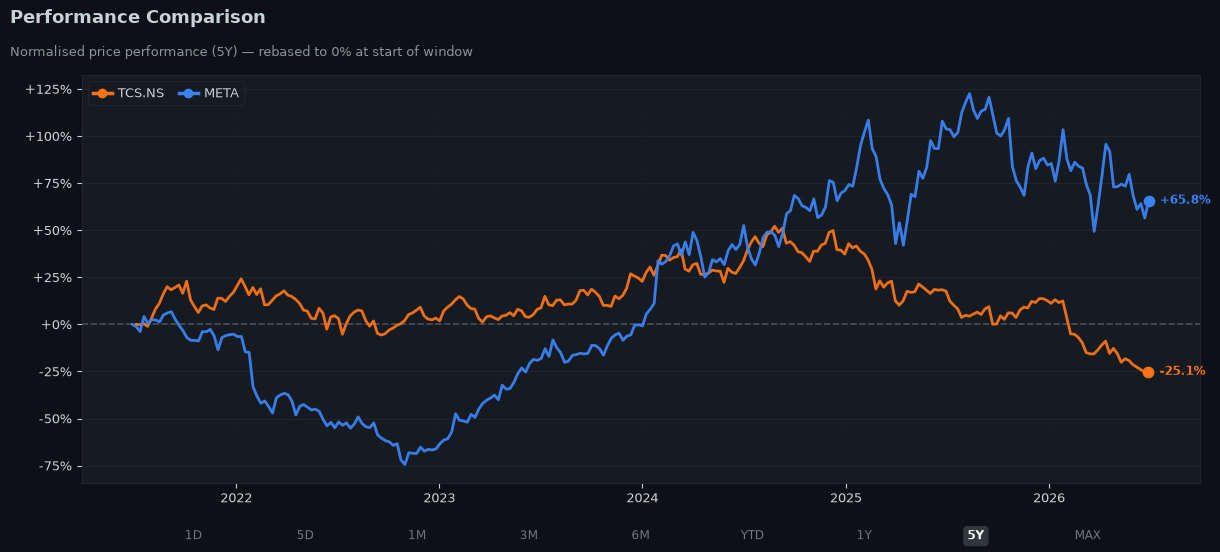


✅ Chart saved to performance_comparison.png  |  Window: 5Y
   Tickers plotted: ['TCS.NS', 'META']


In [9]:
#· Performance Comparison Chart


import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# ── Time window selector ───────────────────────────────────────────────────
WINDOW_MAP = {
    '1D':  (1,    '1d',  '5m',   mdates.HourLocator(interval=1),   mdates.DateFormatter('%H:%M')),
    '5D':  (5,    '5d',  '30m',  mdates.DayLocator(interval=1),    mdates.DateFormatter('%b %d')),
    '1M':  (30,   '1mo', '1d',   mdates.WeekdayLocator(interval=1),mdates.DateFormatter('%b %d')),
    '3M':  (90,   '3mo', '1d',   mdates.MonthLocator(),            mdates.DateFormatter('%b %Y')),
    '6M':  (180,  '6mo', '1d',   mdates.MonthLocator(),            mdates.DateFormatter('%b %Y')),
    'YTD': (None, 'ytd', '1d',   mdates.MonthLocator(),            mdates.DateFormatter('%b %Y')),
    '1Y':  (365,  '1y',  '1d',   mdates.MonthLocator(interval=2),  mdates.DateFormatter('%b %Y')),
    '2Y':  (730,  '2y',  '1wk',  mdates.MonthLocator(interval=3),  mdates.DateFormatter('%b %Y')),
    '3Y':  (1095, '5y',  '1wk',  mdates.MonthLocator(interval=4),  mdates.DateFormatter('%b %Y')),
    '5Y':  (1825, '5y',  '1wk',  mdates.YearLocator(),             mdates.DateFormatter('%Y')),
    'MAX': (None, 'max', '1mo',  mdates.YearLocator(),             mdates.DateFormatter('%Y')),
}
VALID_WINDOWS = list(WINDOW_MAP.keys())

while True:
    raw_window = input(f'Enter time window ({', '.join(VALID_WINDOWS)}): ').strip().upper()
    if raw_window in WINDOW_MAP:
        TIME_WINDOW = raw_window
        break
    print(f'  ⚠️  "{raw_window}" not recognised. Valid options: {', '.join(VALID_WINDOWS)}')

days, period, interval, x_loc, x_fmt = WINDOW_MAP[TIME_WINDOW]

# ── Fetch daily/intraday price data for the chosen window ──────────────────
price_data = {}
for ticker in tickers:
    try:
        t = yf.Ticker(ticker)
        hist = t.history(period=period, interval=interval)['Close'].dropna()
        if len(hist) > 1:
            price_data[ticker.upper()] = hist
    except Exception as e:
        print(f'  ⚠️  {ticker}: {e}')

# ── Normalize: rebase every series to 0% at start of window ────────────────
normalized = {}
for ticker, series in price_data.items():
    base = series.iloc[0]
    if base != 0:
        normalized[ticker] = ((series - base) / base) * 100

# ── Plot ───────────────────────────────────────────────────────────────────
DARK_BG   = '#0d1117'
PANEL_BG  = '#161b22'
GRID_COL  = '#21262d'
TEXT_COL  = '#c9d1d9'
ZERO_COL  = '#484f58'

# Distinctive colour palette (matches screenshot style)
PALETTE = [
    '#f97316',  # orange
    '#3b82f6',  # blue
    '#22c55e',  # green
    '#a855f7',  # purple
    '#ec4899',  # pink
    '#14b8a6',  # teal
    '#eab308',  # yellow
    '#ef4444',  # red
]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(PANEL_BG)

# Grid
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:+.0f}%'))
ax.grid(axis='y', color=GRID_COL, linewidth=0.7, linestyle='-')
ax.grid(axis='x', color=GRID_COL, linewidth=0.4, linestyle=':')
ax.axhline(0, color=ZERO_COL, linewidth=1.2, linestyle='--', zorder=3)

# Plot each ticker
legend_handles = []
for i, (ticker, series) in enumerate(normalized.items()):
    color = PALETTE[i % len(PALETTE)]
    ax.plot(series.index, series.values,
            color=color, linewidth=2.0, alpha=0.95, zorder=4)

    # End-point dot + label
    last_x, last_y = series.index[-1], series.values[-1]
    ax.scatter([last_x], [last_y], color=color, s=55, zorder=6)
    ax.annotate(f'{last_y:+.1f}%',
                xy=(last_x, last_y),
                xytext=(8, 0), textcoords='offset points',
                color=color, fontsize=8.5, fontweight='bold', va='center')

    legend_handles.append(
        Line2D([0], [0], color=color, linewidth=2.5,
               marker='o', markersize=6, label=ticker)
    )

# Axes styling
ax.xaxis.set_major_locator(x_loc)
ax.xaxis.set_major_formatter(x_fmt)
ax.tick_params(colors=TEXT_COL, labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor(GRID_COL)
plt.setp(ax.get_xticklabels(), rotation=0, ha='center')

# Legend (pill-style, top-left — matches screenshot)
legend = ax.legend(
    handles=legend_handles,
    loc='upper left',
    frameon=True,
    framealpha=0.85,
    facecolor=PANEL_BG,
    edgecolor=GRID_COL,
    fontsize=9,
    labelcolor=TEXT_COL,
    ncol=min(4, len(normalized)),
    handlelength=1.5,
    handletextpad=0.5,
    columnspacing=1.2,
)

# Time-window button strip (decorative — shows active window)
all_windows = ['1D', '5D', '1M', '3M', '6M', 'YTD', '1Y', '5Y', 'MAX']
btn_y = -0.13
btn_spacing = 1 / (len(all_windows) + 1)
for j, w in enumerate(all_windows):
    x_pos = (j + 1) * btn_spacing
    is_active = (w == TIME_WINDOW)
    ax.annotate(
        w,
        xy=(x_pos, btn_y),
        xycoords='axes fraction',
        ha='center', va='center',
        fontsize=8.5,
        color='#ffffff' if is_active else '#6e7681',
        fontweight='bold' if is_active else 'normal',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='#30363d' if is_active else 'none',
            edgecolor='#30363d' if is_active else 'none',
        )
    )

# Titles
fig.text(0.015, 0.97, 'Performance Comparison',
         color=TEXT_COL, fontsize=13, fontweight='bold', va='top')
fig.text(0.015, 0.91,
         f'Normalised price performance ({TIME_WINDOW}) — rebased to 0% at start of window',
         color='#8b949e', fontsize=9, va='top')

plt.subplots_adjust(left=0.07, right=0.93, top=0.86, bottom=0.18)
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print(f'\n✅ Chart saved to performance_comparison.png  |  Window: {TIME_WINDOW}')
print(f'   Tickers plotted: {list(normalized.keys())}')

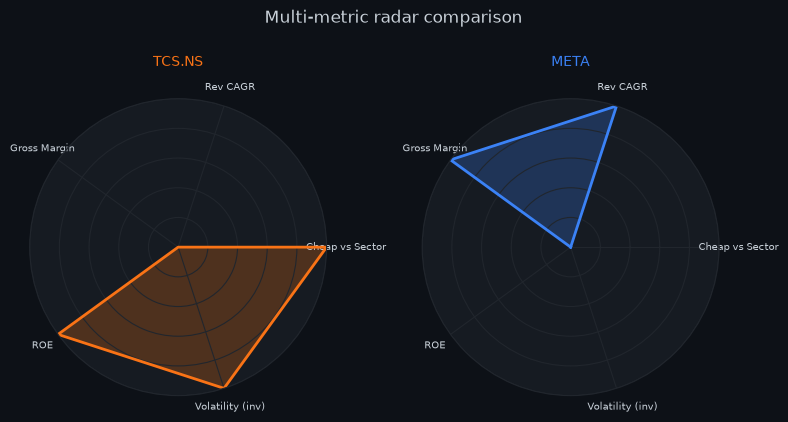

In [10]:
#Radar / spider chart (most impressive for multi-stock comparison)

import matplotlib.pyplot as plt
import numpy as np

def plot_radar(df):
    metrics = ['pe_vs_sector', 'revenue_cagr_5y', 'gross_margin', 'roe', 'ann_volatility']
    labels  = ['Cheap vs Sector', 'Rev CAGR', 'Gross Margin', 'ROE', 'Volatility (inv)']
    
    # Normalise 0–1, invert volatility so higher = better everywhere
    normed = df[metrics].copy()
    for col in metrics:
        mn, mx = normed[col].min(), normed[col].max()
        normed[col] = (normed[col] - mn) / (mx - mn + 1e-9)
    normed['pe_vs_sector']  = 1 - normed['pe_vs_sector']   # lower P/E = better
    normed['ann_volatility'] = 1 - normed['ann_volatility'] # lower vol = better

    N = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, axes = plt.subplots(1, len(df), figsize=(4 * len(df), 4),
                             subplot_kw=dict(polar=True))
    if len(df) == 1:
        axes = [axes]
    
    fig.patch.set_facecolor('#0d1117')
    PALETTE = ['#f97316','#3b82f6','#22c55e','#a855f7','#ec4899','#14b8a6']

    for ax, (_, row), color in zip(axes, normed.iterrows(), PALETTE):
        values = row[metrics].tolist() + [row[metrics[0]]]
        ax.set_facecolor('#161b22')
        ax.plot(angles, values, color=color, linewidth=2)
        ax.fill(angles, values, alpha=0.25, color=color)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, size=7, color='#c9d1d9')
        ax.set_yticklabels([])
        ax.set_ylim(0, 1)
        ax.tick_params(colors='#c9d1d9')
        ax.spines['polar'].set_color('#21262d')
        ax.grid(color='#21262d')
        ticker = df.loc[row.name, 'ticker'] if 'ticker' in df.columns else ''
        ax.set_title(ticker, color=color, fontsize=10, pad=12)

    plt.suptitle('Multi-metric radar comparison', color='#c9d1d9', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()

plot_radar(screened_df)

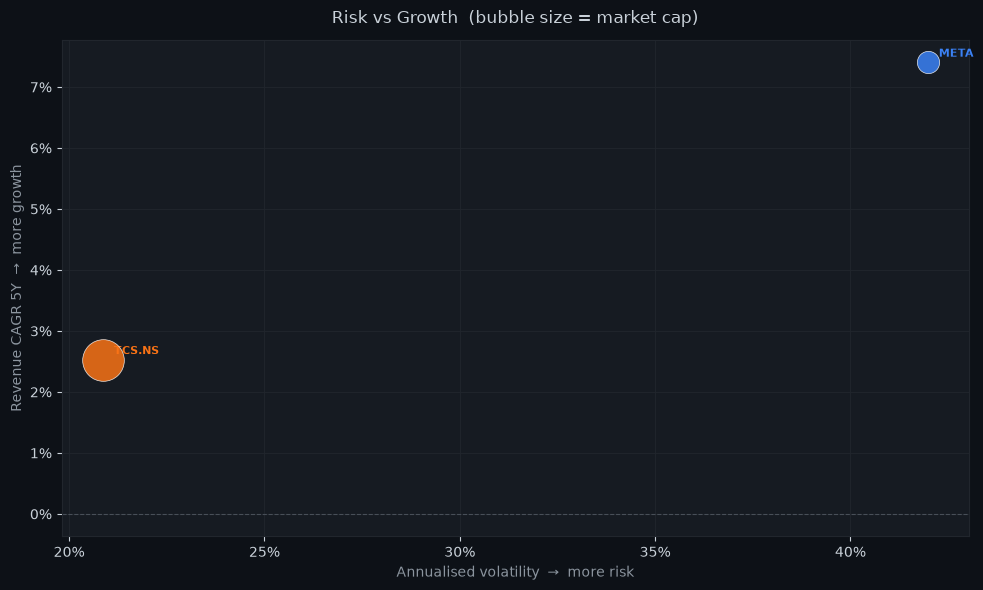

In [11]:
#Risk vs return scatter (classic quant visual)
def plot_risk_return(df):
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#161b22')
    ax.grid(color='#21262d', linewidth=0.6)

    # Bubble size = market cap (normalised)
    mcap = df['market_cap'].fillna(df['market_cap'].median())
    sizes = ((mcap / mcap.max()) * 800 + 100).values

    PALETTE = ['#f97316','#3b82f6','#22c55e','#a855f7','#ec4899','#14b8a6','#eab308','#ef4444']

    for i, (_, row) in enumerate(df.iterrows()):
        x = row.get('ann_volatility', np.nan)
        y = row.get('revenue_cagr_5y', np.nan)
        if pd.isna(x) or pd.isna(y):
            continue
        color = PALETTE[i % len(PALETTE)]
        ax.scatter(x, y, s=sizes[i], color=color, alpha=0.85, zorder=4, edgecolors='white', linewidths=0.5)
        ax.annotate(row['ticker'], (x, y), textcoords='offset points',
                    xytext=(8, 4), fontsize=8, color=color, fontweight='bold')

    ax.axhline(0, color='#484f58', linewidth=0.8, linestyle='--')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
    ax.set_xlabel('Annualised volatility  →  more risk', color='#8b949e', fontsize=10)
    ax.set_ylabel('Revenue CAGR 5Y  →  more growth', color='#8b949e', fontsize=10)
    ax.tick_params(colors='#c9d1d9')
    for spine in ax.spines.values():
        spine.set_edgecolor('#21262d')
    ax.set_title('Risk vs Growth  (bubble size = market cap)', color='#c9d1d9', fontsize=12, pad=12)

    plt.tight_layout()
    plt.savefig('risk_return_scatter.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()

plot_risk_return(screened_df)

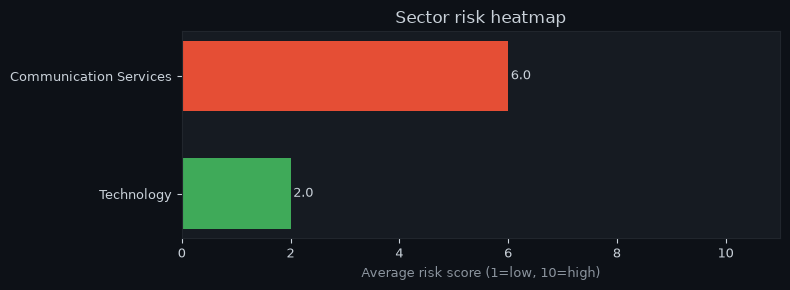

In [12]:
#Sector heatmap (portfolio-level thinking)
def plot_sector_heatmap(df):
    pivot = df.pivot_table(index='sector', values='risk_score', aggfunc='mean').dropna()
    pivot = pivot.sort_values('risk_score')

    fig, ax = plt.subplots(figsize=(8, max(3, len(pivot) * 0.55)))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#161b22')

    colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(pivot)))
    bars = ax.barh(pivot.index, pivot['risk_score'], color=colors, height=0.6)

    for bar, val in zip(bars, pivot['risk_score']):
        ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}', va='center', color='#c9d1d9', fontsize=9)

    ax.set_xlim(0, 11)
    ax.set_xlabel('Average risk score (1=low, 10=high)', color='#8b949e', fontsize=9)
    ax.tick_params(colors='#c9d1d9', labelsize=9)
    ax.set_title('Sector risk heatmap', color='#c9d1d9', fontsize=12)
    for spine in ax.spines.values():
        spine.set_edgecolor('#21262d')

    plt.tight_layout()
    plt.savefig('sector_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()

plot_sector_heatmap(screened_df)

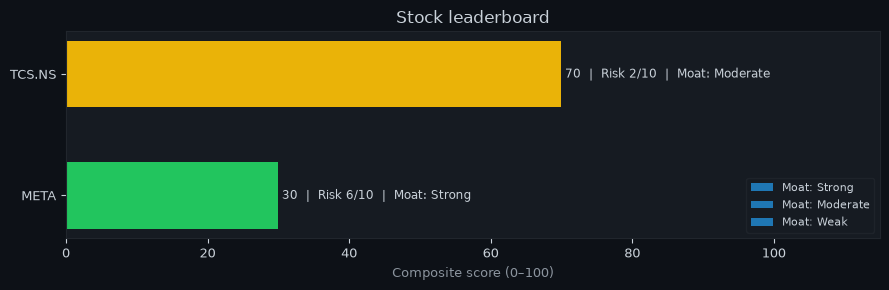

In [13]:
#Composite score leaderboard (clean output for non-technical readers)
def plot_leaderboard(df):
    data = df[['ticker', 'composite_score', 'moat_rating', 'risk_score']].dropna(subset=['composite_score'])
    data = data.sort_values('composite_score', ascending=True)

    moat_colors = {'Strong': '#22c55e', 'Moderate': '#eab308', 'Weak': '#ef4444'}
    bar_colors  = [moat_colors.get(m, '#3b82f6') for m in data['moat_rating']]

    fig, ax = plt.subplots(figsize=(9, max(3, len(data) * 0.55)))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#161b22')

    bars = ax.barh(data['ticker'], data['composite_score'], color=bar_colors, height=0.55)

    for bar, (_, row) in zip(bars, data.iterrows()):
        score = row['composite_score']
        ax.text(score + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{score:.0f}  |  Risk {row['risk_score']}/10  |  Moat: {row['moat_rating']}",
                va='center', color='#c9d1d9', fontsize=8.5)

    ax.set_xlim(0, 115)
    ax.set_xlabel('Composite score (0–100)', color='#8b949e', fontsize=9)
    ax.tick_params(colors='#c9d1d9', labelsize=9)
    ax.set_title('Stock leaderboard', color='#c9d1d9', fontsize=12)
    for spine in ax.spines.values():
        spine.set_edgecolor('#21262d')

    # Moat legend
    for label, color in moat_colors.items():
        ax.barh([], [], color=color, label=f'Moat: {label}')
    ax.legend(loc='lower right', facecolor='#161b22', edgecolor='#21262d',
              labelcolor='#c9d1d9', fontsize=8)

    plt.tight_layout()
    plt.savefig('leaderboard.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()

plot_leaderboard(screened_df)

In [14]:
import time

for _, row in screened_df.iterrows():
    print(f"REPORT FOR {row['ticker']}")
    print("=" * 100)
    report = generate_report(row)
    print(report)
    print("\n")
    time.sleep(15)  # wait 15 seconds between each ticker

REPORT FOR TCS.NS
Our investment thesis is that Tata Consultancy Services Limited (TCS.NS) is an attractive long-term investment opportunity, driven by its reasonable valuation, stable growth prospects, and strong financials.

Key positives for the stock include its trailing P/E of 15.4x and forward P/E of 12.7x, which is 0.8x relative to its sector, indicating a relatively undervalued position. Additionally, the company's gross margin of 40.3%, net margin of 18.6%, and ROE of 48.4% demonstrate its ability to maintain profitability. The debt-to-equity ratio of 10.39 and current ratio of 2.23 also highlight the company's healthy balance sheet.

However, key risks include the company's moderate moat rating and relatively low revenue CAGR of 2.5% over the past five years, which may impact its long-term growth prospects. Furthermore, despite the low risk score of 2/10, the stock's volatility of 20.9% and beta of 0.24 may still pose some risks to investors.

Based on the analyst consensus "

In [15]:
import os

# Create data folder if it doesn't exist
os.makedirs("data", exist_ok=True)

# Save Excel workbook
with pd.ExcelWriter(
    "data/stock_analysis.xlsx",
    engine="openpyxl"
) as writer:

    raw_df.to_excel(
        writer,
        sheet_name="Raw Data",
        index=False
    )

    metrics_df.to_excel(
        writer,
        sheet_name="Metrics",
        index=False
    )

    screened_df.to_excel(
        writer,
        sheet_name="Screened Stocks",
        index=False
    )

# Save screened stocks separately
screened_df.to_csv(
    "data/screened_stocks.csv",
    index=False
)

screened_df.to_excel(
    "data/screened_stocks.xlsx",
    index=False
)

print("✅ Files saved successfully!")
print("   data/stock_analysis.xlsx")
print("   data/screened_stocks.csv")
print("   data/screened_stocks.xlsx")

✅ Files saved successfully!
   data/stock_analysis.xlsx
   data/screened_stocks.csv
   data/screened_stocks.xlsx
